In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_blobs
X, y=make_blobs(n_samples=1000, n_features=2, centers=3, random_state=1)

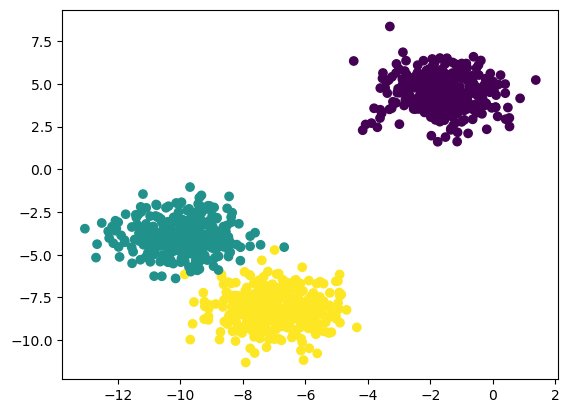

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=1)

In [5]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3)

In [6]:
kmeans.fit(X_train)  #fit_predict can also be used

KMeans(n_clusters=3)

In [7]:

y_labels=kmeans.predict(X_train)

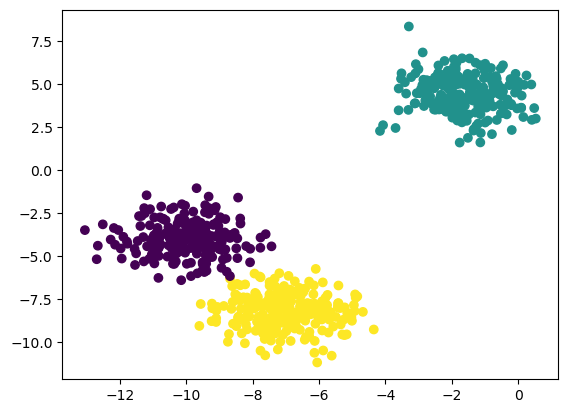

In [8]:

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_labels)

In [9]:
# /how the model is good
from sklearn.metrics import silhouette_score
silhouette_score(X_train, kmeans.labels_) #if close to 1 -> good model

np.float64(0.7179451230427786)

In [10]:
kmeans.inertia_ # k=3, wcss distance

1405.680051784939

In [11]:
# how to select k
wcss=[]
for i in range(1, 10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [12]:
wcss #wcss decreasing if k increasing

[29004.51174361046,
 4501.242392684224,
 1405.680051784939,
 1218.7499732436956,
 1105.7522136473651,
 938.6148591798516,
 803.3171994981548,
 712.4199779774085,
 623.1206477048431]

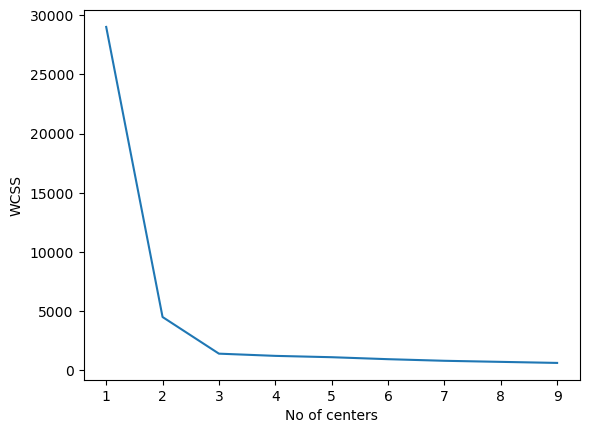

In [13]:
# plot the elbow curve
plt.plot(range(1,10), wcss)
plt.xticks(range(1,10))
plt.xlabel('No of centers')
plt.ylabel('WCSS')
plt.show()

In [14]:
# based on above plot, the optimal k/centroid is 3

In [15]:
scores=[]
for i in range(2, 10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(X_train)
    score=silhouette_score(X_train, kmeans.labels_)
    scores.append(score)
scores

[np.float64(0.7674998364431159),
 np.float64(0.7179451230427786),
 np.float64(0.5662867882869406),
 np.float64(0.4803630162316363),
 np.float64(0.42197434657413524),
 np.float64(0.32587095371312624),
 np.float64(0.32888141444975827),
 np.float64(0.34543942065369565)]